<a href="https://colab.research.google.com/github/jaumg2004/Academia-Digital/blob/main/lab/c24_2026_1_ll_atividade_08_mmmm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **`Inatel - C24 (Inteligência Artificial) - 2026/1`**

# <font color='green'>**Atividade 08: RNN**</font>

## <font color='#2D9CDB'>**LEIA ATENTAMENTE AS INSTRUÇÕES A SEGUIR**</font>
- Importe este notebook no [Google Colab](https://colab.research.google.com/) para resolver os exercícios;
- Consulte o material disponibilizado pelo Prof. Felipe Figueiredo para revisar os conceitos;
- Utilize os recursos disponíveis na Internet (documentações e artigos científicos) para complementar seus estudos;
- <font color='red'>**A ATIVIDADE DEVERÁ SER REALIZADA COM O [MONITOR](mailto:matheus.botelho@ges.inatel.br) EM UM DOS SEGUINTES HORÁRIOS:**</font>

| Monitor                       | Dia           | Hora                               | Local           |
|-------------------------------|---------------|------------------------------------|---------------- |
| Matheus Botelho Sampaio Netto | Terça-feira   | <font color='orange'>17:30</font>  | 1.4 (prédio VI) |
| Matheus Botelho Sampaio Netto | Quinta-feira  | <font color='orange'>17:30</font>  | 1.4 (prédio VI) |
| Matheus Botelho Sampaio Netto | Sábado        | <font color='#2D9CDB'>10:00</font> | Teams (ao vivo) |
| Matheus Botelho Sampaio Netto | Sábado        | <font color='#2D9CDB'>13:30</font> | Teams (ao vivo) |

- <font color='red'>**NÃO**</font> remova as células de Código já presentes neste notebook;
- <font color='red'>**NÃO**</font> modifique as células de Markdown (em <font color='green'>verde</font> ou <font color='#2D9CDB'>azul</font>) presentes neste notebook;
- Após cada questão, há uma célula para você implementar e responder a questão;
- É permitido adicionar mais células (de código ou markdown) antes da próxima pergunta;
- Caso precise utilizar bibliotecas que não estão instaladas nativamente no Colab, inclua uma célula de código com o comando de instalação.</font>
  - Exemplo: `!pip install nome_da_biblioteca`
- <font color='red'>**Renomeie os termos `LL` para `sua_turma_de_laboratorio` e `MMMM` para `seu_numero_de_matricula` no nome do arquivo.**</font>
  - Exemplo: `C24_2026_1_L1_Atividade_08_1234.ipynb`)
- <font color='magenta'>**Faça download do notebook com a resolução no Google Colab, mantendo a saída de todas as células, e anexe-o à tarefa do Teams.**</font>

# <font color='green'><u><b>Preparação</b></u></font>

In [25]:
!pip install tensorflow numpy pandas matplotlib seaborn scikit-learn

In [26]:
import time
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import tensorflow as tf
import os

from sklearn.preprocessing import MinMaxScaler

tf.random.set_seed(42)
np.random.seed(42)

# <font color='green'><u><b>Parte 1 - Conjunto de Dados</b></u></font>

Não altere o conteúdo da célula a seguir!

In [27]:
zip_path = tf.keras.utils.get_file(
    fname="jena_climate_2009_2016.csv.zip",
    origin="https://storage.googleapis.com/tensorflow/tf-keras-datasets/jena_climate_2009_2016.csv.zip",
    cache_dir=os.getcwd(),
    extract=True
)

csv_path = os.path.join(os.path.splitext(zip_path)[0], 'jena_climate_2009_2016.csv')

target_col = "T (degC)"

temperature = pd.read_csv(csv_path)[target_col].values.reshape(-1, 1)

temperature

array([[-8.02],
       [-8.41],
       [-8.51],
       ...,
       [-3.16],
       [-4.23],
       [-4.82]])

### <font color='#2D9CDB'>Q1) O dataset [Jena Climate](https://www.kaggle.com/datasets/mnassrib/jena-climate) é amplamente utilizado no estudo de redes neurais recorrentes (RNNs), LSTMs e previsão de séries temporais. Pesquise brevemente sobre o dataset e descreva, em um único parágrafo, o domínio de aplicação da base de dados, o objetivo para o qual ela foi criada, o período de coleta dos dados, os tipos de variáveis meteorológicas registradas e por que esse conjunto de dados é adequado para problemas de previsão temporal utilizando redes neurais recorrentes.</font>

 O Jena Climate é um conjunto de dados meteorológicos obtido em uma estação do Max Planck Institute for Biogeochemistry, localizada em Jena, Alemanha. O recorte utilizado nesta atividade reúne medições realizadas em intervalos de 10 minutos entre 2009 e 2016. A base registra variáveis como temperatura do ar, pressão atmosférica, umidade relativa, ponto de orvalho, pressão de vapor, concentração de vapor d'água, densidade do ar, velocidade média e máxima do vento e direção do vento. O conjunto de dados é adequado para problemas de previsão temporal porque suas observações são organizadas cronologicamente e apresentam dependências entre medições consecutivas, oscilações diárias, variações sazonais e padrões de curto e longo prazo que podem ser aprendidos por redes neurais recorrentes, como as LSTMs.

### <font color='#2D9CDB'>Q2) Utilizando a variável <code>temperature</code>, plote a série temporal completa de temperaturas registradas no dataset. Em seguida, informe a quantidade total de amostras, a temperatura mínima, a temperatura máxima, a temperatura média e o desvio padrão da série. Com base no gráfico obtido, descreva brevemente os padrões observados, comentando sobre possíveis tendências, sazonalidades e variações ao longo do tempo.</font>

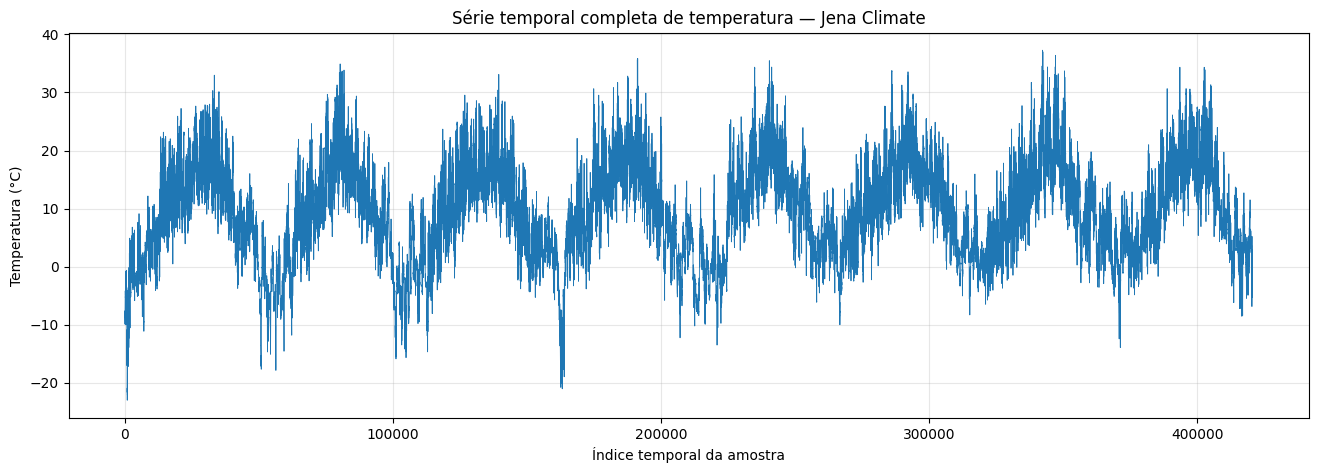

,Métrica,Valor
0,Quantidade total de amostras,420551.000000
1,Temperatura mínima (°C),-23.010000
2,Temperatura máxima (°C),37.280000
3,Temperatura média (°C),9.450147
4,Desvio padrão (°C),8.423355


In [28]:
temperature_1d = temperature.ravel()

plt.figure(figsize=(16, 5))
plt.plot(temperature_1d, linewidth=0.6)
plt.title("Série temporal completa de temperatura — Jena Climate")
plt.xlabel("Índice temporal da amostra")
plt.ylabel("Temperatura (°C)")
plt.grid(alpha=0.3)
plt.show()

stats_temperature = pd.DataFrame({
    "Métrica": [
        "Quantidade total de amostras",
        "Temperatura mínima (°C)",
        "Temperatura máxima (°C)",
        "Temperatura média (°C)",
        "Desvio padrão (°C)",
    ],
    "Valor": [
        len(temperature_1d),
        temperature_1d.min(),
        temperature_1d.max(),
        temperature_1d.mean(),
        temperature_1d.std(),
    ],
})

display(stats_temperature)

A série temporal apresenta oscilações recorrentes associadas às estações do ano. Os períodos mais quentes e mais frios voltam a ocorrer ao longo dos anos, caracterizando uma sazonalidade anual. Também existem variações de curto prazo relacionadas às mudanças meteorológicas diárias. O gráfico não indica uma tendência monotônica contínua de crescimento ou redução da temperatura durante todo o período analisado. Os valores exatos da quantidade de amostras, da temperatura mínima, da temperatura máxima, da média e do desvio padrão são apresentados na tabela gerada pela célula anterior.

### <font color='#2D9CDB'>Q3) Divida a série temporal em três subconjuntos: treinamento (60%), validação (20%) e teste (20%), preservando a ordem temporal das amostras. Informe a quantidade de amostras em cada subconjunto e explique por que, em problemas de previsão temporal, não é adequado embaralhar os dados antes da divisão.</font>

In [29]:
n_total = len(temperature)

n_train = int(0.60 * n_total)
n_val = int(0.20 * n_total)

train_data = temperature[:n_train]
val_data = temperature[n_train:n_train + n_val]
test_data = temperature[n_train + n_val:]

split_sizes = pd.DataFrame({
    "Subconjunto": [
        "Treinamento",
        "Validação",
        "Teste",
        "Total",
    ],
    "Quantidade de amostras": [
        len(train_data),
        len(val_data),
        len(test_data),
        n_total,
    ],
    "Percentual aproximado": [
        100 * len(train_data) / n_total,
        100 * len(val_data) / n_total,
        100 * len(test_data) / n_total,
        100.0,
    ],
})

display(split_sizes)

,Subconjunto,Quantidade de amostras,Percentual aproximado
0,Treinamento,252330,59.999857
1,Validação,84110,19.999952
2,Teste,84111,20.000190
3,Total,420551,100.000000


A divisão foi realizada preservando a ordem cronológica da série: as primeiras 60% das observações foram destinadas ao treinamento, as 20% seguintes à validação e as 20% finais ao teste. Em um problema de previsão temporal, os dados não devem ser embaralhados antes da divisão, pois isso poderia fazer com que informações futuras fossem utilizadas durante o treinamento. Esse problema é chamado de vazamento de dados (*data leakage*) e resultaria em uma avaliação pouco realista da capacidade preditiva do modelo.

### <font color='#2D9CDB'>Q4) Normalize os conjuntos de treinamento, validação e teste utilizando a técnica Min-Max Scaling, de forma que os valores fiquem no intervalo [0, 1]. Apresente os valores mínimo e máximo do conjunto de treinamento antes e depois da normalização e explique brevemente por que a normalização é importante para o treinamento de redes neurais.</font>

In [30]:
scaler = MinMaxScaler(feature_range=(0, 1))

# O scaler é ajustado somente com os dados de treinamento.
train_scaled = scaler.fit_transform(train_data)

# Os conjuntos futuros utilizam os parâmetros obtidos no treino.
val_scaled = scaler.transform(val_data)
test_scaled = scaler.transform(test_data)

normalization_summary = pd.DataFrame({
    "Conjunto de treinamento": [
        "Antes da normalização",
        "Depois da normalização",
    ],
    "Mínimo": [
        train_data.min(),
        train_scaled.min(),
    ],
    "Máximo": [
        train_data.max(),
        train_scaled.max(),
    ],
})

display(normalization_summary)

,Conjunto de treinamento,Mínimo,Máximo
0,Antes da normalização,-23.01,35.86
1,Depois da normalização,0.00,1.00


O `MinMaxScaler` foi ajustado somente com o conjunto de treinamento e posteriormente aplicado aos conjuntos de validação e teste. Esse procedimento evita o vazamento de informações futuras. A normalização é importante porque coloca os valores em uma escala adequada, melhora a estabilidade numérica e facilita o processo de otimização dos pesos da rede neural. No conjunto de treinamento, os valores passam a ocupar o intervalo entre 0 e 1. Caso os conjuntos de validação ou teste contenham valores inéditos fora dos extremos observados no treinamento, eles podem apresentar valores ligeiramente menores que 0 ou maiores que 1.

# <font color='green'><u><b>Parte 2 - Preparação das Séries Temporais</b></u></font>

### <font color='#2D9CDB'>Q5) Para treinar uma LSTM, é necessário organizar a série temporal em sequências de entrada e saídas desejadas. Implemente uma função chamada <code>create_sequences()</code> que utilize uma janela temporal de 30 amostras, de forma que cada entrada seja composta pelas 30 temperaturas anteriores e a saída corresponda à temperatura seguinte. Gere os conjuntos de treinamento, validação e teste e informe as dimensões de <code>X_train</code> e <code>y_train</code>. Explique brevemente o significado de cada dimensão.</font>

In [31]:
def create_sequences(data, window_size=30):
    """
    Cria pares de entrada e saída para previsão temporal.

    Cada entrada possui `window_size` amostras consecutivas.
    Cada saída corresponde ao valor imediatamente posterior.
    """
    X = []
    y = []

    for i in range(len(data) - window_size):
        X.append(data[i:i + window_size])
        y.append(data[i + window_size])

    return (
        np.asarray(X, dtype=np.float32),
        np.asarray(y, dtype=np.float32),
    )


WINDOW_SIZE = 30

X_train, y_train = create_sequences(train_scaled, WINDOW_SIZE)
X_val, y_val = create_sequences(val_scaled, WINDOW_SIZE)
X_test, y_test = create_sequences(test_scaled, WINDOW_SIZE)

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_val:  ", X_val.shape)
print("y_val:  ", y_val.shape)

print("X_test: ", X_test.shape)
print("y_test: ", y_test.shape)

X_train: (252300, 30, 1)
y_train: (252300, 1)
X_val:   (84080, 30, 1)
y_val:   (84080, 1)
X_test:  (84081, 30, 1)
y_test:  (84081, 1)


Cada entrada da rede contém uma janela com as 30 temperaturas anteriores, enquanto a saída correspondente representa a temperatura imediatamente seguinte. Em `X_train`, a primeira dimensão indica a quantidade de sequências disponíveis, a segunda representa os 30 passos temporais utilizados como entrada e a terceira representa a única variável analisada: a temperatura. Em `y_train`, cada linha contém o valor-alvo associado a uma sequência de entrada. Para o conjunto original sem alterações, a saída esperada é `X_train = (252300, 30, 1)` e `y_train = (252300, 1)`.

### <font color='#2D9CDB'>Q6) Exiba graficamente a primeira sequência presente em <code>X_train</code> e destaque o valor correspondente em <code>y_train</code>. Explique como essa sequência será utilizada pela LSTM para realizar a previsão da próxima temperatura.</font>

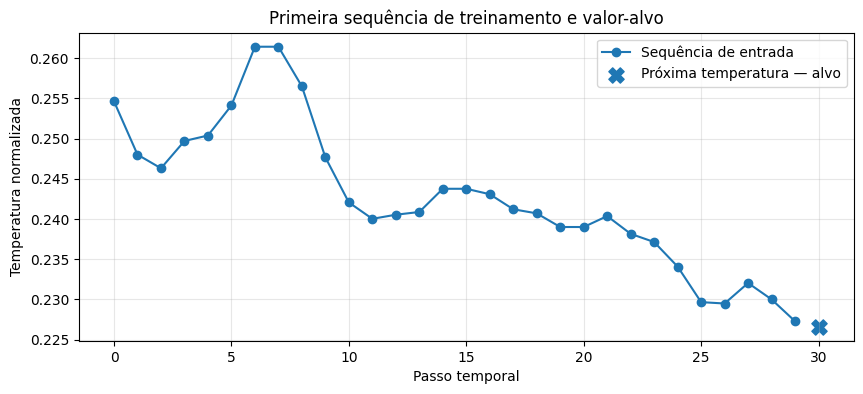

Valor-alvo normalizado: 0.226601
Valor-alvo em °C: -9.67


In [32]:
first_sequence = X_train[0, :, 0]
first_target = y_train[0, 0]

plt.figure(figsize=(10, 4))

plt.plot(
    range(WINDOW_SIZE),
    first_sequence,
    marker="o",
    label="Sequência de entrada",
)

plt.scatter(
    WINDOW_SIZE,
    first_target,
    marker="X",
    s=120,
    label="Próxima temperatura — alvo",
)

plt.title("Primeira sequência de treinamento e valor-alvo")
plt.xlabel("Passo temporal")
plt.ylabel("Temperatura normalizada")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

print(f"Valor-alvo normalizado: {first_target:.6f}")

target_celsius = scaler.inverse_transform([[first_target]])[0, 0]

print(f"Valor-alvo em °C: {target_celsius:.2f}")

A LSTM recebe as 30 temperaturas normalizadas respeitando a ordem cronológica. Em cada passo temporal, a camada recorrente atualiza seus estados internos para preservar informações relevantes sobre a evolução recente da temperatura. Após processar toda a sequência, a camada de saída utiliza a representação produzida pela LSTM para estimar a temperatura do próximo instante.

# <font color='green'><u><b>Parte 3 - Construindo a Primeira LSTM</b></u></font>

### <font color='#2D9CDB'>Q7) Construa uma rede neural recorrente composta por uma camada LSTM com uma unidade de memória e uma camada de saída totalmente conectada com um neurônio. Utilize a função de perda MSE (<code>mean_squared_error</code>) e o otimizador Adam. Apresente o resumo da arquitetura gerado pelo método <code>summary()</code> e informe o número total de parâmetros treináveis do modelo.</font>

In [33]:
def build_lstm_model(units, window_size):
    """
    Cria uma LSTM seguida por uma camada densa com uma saída.
    """
    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(42)

    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(window_size, 1)),
        tf.keras.layers.LSTM(units),
        tf.keras.layers.Dense(1),
    ])

    model.compile(
        optimizer="adam",
        loss="mean_squared_error",
    )

    return model


model_1 = build_lstm_model(
    units=1,
    window_size=WINDOW_SIZE,
)

model_1.summary()

print("Parâmetros treináveis:", model_1.count_params())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 1)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14 (56.00 B)

 Trainable params: 14 (56.00 B)

 Non-trainable params: 0 (0.00 B)

Parâmetros treináveis: 14


O modelo possui uma camada LSTM com uma unidade de memória e uma camada densa com um neurônio de saída. A arquitetura possui **14 parâmetros treináveis** no total: 12 parâmetros pertencem à camada LSTM e 2 parâmetros pertencem à camada densa.

### <font color='#2D9CDB'>Q8) Treine o modelo por 10 épocas utilizando os conjuntos de treinamento e validação. Em seguida, plote as curvas de perda de treinamento e validação ao longo das épocas. Com base nos gráficos obtidos, descreva brevemente o comportamento do treinamento e indique se há evidências de sobreajuste (overfitting) ou problemas de generalização.</font>

Epoch 1/10
1972/1972 ━━━━━━━━━━━━━━━━━━━━ 32s 13ms/step - loss: 0.0267 - val_loss: 0.0063
Epoch 2/10
1972/1972 ━━━━━━━━━━━━━━━━━━━━ 21s 10ms/step - loss: 0.0028 - val_loss: 0.0014
Epoch 3/10
1972/1972 ━━━━━━━━━━━━━━━━━━━━ 42s 11ms/step - loss: 5.3338e-04 - val_loss: 1.0087e-04
Epoch 4/10
1972/1972 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - loss: 1.6294e-04 - val_loss: 7.8097e-05
Epoch 5/10
1972/1972 ━━━━━━━━━━━━━━━━━━━━ 22s 11ms/step - loss: 1.3284e-04 - val_loss: 6.0902e-05
Epoch 6/10
1972/1972 ━━━━━━━━━━━━━━━━━━━━ 24s 12ms/step - loss: 1.0905e-04 - val_loss: 5.0823e-05
Epoch 7/10
1972/1972 ━━━━━━━━━━━━━━━━━━━━ 21s 10ms/step - loss: 8.9741e-05 - val_loss: 4.3838e-05
Epoch 8/10
1972/1972 ━━━━━━━━━━━━━━━━━━━━ 42s 11ms/step - loss: 7.4589e-05 - val_loss: 3.8712e-05
Epoch 9/10
1972/1972 ━━━━━━━━━━━━━━━━━━━━ 20s 10ms/step - loss: 6.2674e-05 - val_loss: 3.4913e-05
Epoch 10/10
1972/1972 ━━━━━━━━━━━━━━━━━━━━ 22s 11ms/step - loss: 5.3362e-05 - val_loss: 3.1957e-05


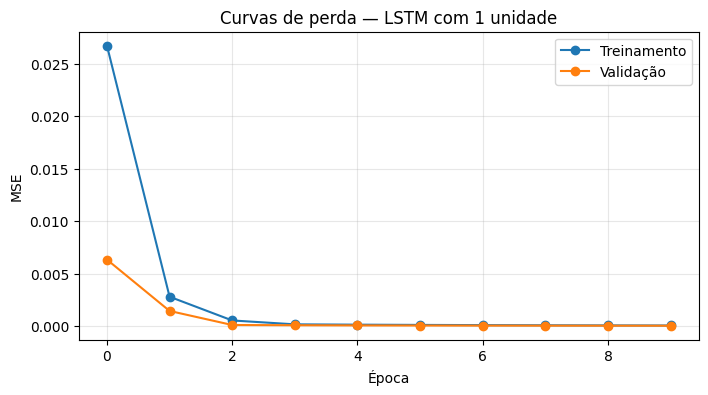

Interpretação automática: não há evidência forte de sobreajuste nas 10 épocas, pois a perda de validação permaneceu próxima do melhor valor obtido.
Tempo médio por época: 26.666 s


In [34]:
def train_model(
    model,
    X_train,
    y_train,
    X_val,
    y_val,
    epochs=10,
    batch_size=128,
):
    """
    Treina um modelo e retorna o histórico e o tempo médio por época.
    """
    start = time.perf_counter()

    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        shuffle=False,
        verbose=1,
    )

    elapsed = time.perf_counter() - start
    avg_time_per_epoch = elapsed / epochs

    return history, avg_time_per_epoch

history_1, time_epoch_1 = train_model(
    model=model_1,
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    epochs=10,
)

plt.figure(figsize=(8, 4))

plt.plot(
    history_1.history["loss"],
    marker="o",
    label="Treinamento",
)

plt.plot(
    history_1.history["val_loss"],
    marker="o",
    label="Validação",
)

plt.title("Curvas de perda — LSTM com 1 unidade")
plt.xlabel("Época")
plt.ylabel("MSE")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

best_val_loss_1 = min(history_1.history["val_loss"])
final_val_loss_1 = history_1.history["val_loss"][-1]

if final_val_loss_1 > 1.10 * best_val_loss_1:
    print(
        "Interpretação automática: há indícios de sobreajuste, "
        "pois a perda de validação aumentou após atingir um valor menor."
    )
else:
    print(
        "Interpretação automática: não há evidência forte de sobreajuste "
        "nas 10 épocas, pois a perda de validação permaneceu próxima "
        "do melhor valor obtido."
    )

print(f"Tempo médio por época: {time_epoch_1:.3f} s")

A perda de treinamento tende a diminuir durante as épocas, indicando que a rede está ajustando seus pesos. A perda de validação deve ser comparada com a perda de treinamento. Quando ambas diminuem e permanecem próximas, não há evidência forte de sobreajuste. Caso a perda de treinamento continue diminuindo enquanto a perda de validação aumenta de forma persistente, existem indícios de *overfitting*. A célula anterior gera o gráfico e apresenta uma interpretação automática baseada nos resultados obtidos durante a execução.

### <font color='#2D9CDB'>Q9) Avalie o modelo utilizando o conjunto de teste e reporte o valor do erro quadrático médio (MSE). Em seguida, explique brevemente o que essa métrica representa no contexto do problema de previsão de temperatura.</font>

In [35]:
mse_1 = model_1.evaluate(
    X_test,
    y_test,
    verbose=0,
)

print(
    f"MSE no conjunto de teste — LSTM com 1 unidade: {mse_1:.8f}"
)

MSE no conjunto de teste — LSTM com 1 unidade: 0.00003595


O valor do MSE é apresentado pela célula anterior. Essa métrica representa a média dos quadrados das diferenças entre as temperaturas normalizadas reais e previstas. Como os erros são elevados ao quadrado, desvios maiores recebem uma penalização mais intensa. Portanto, quanto menor for o MSE, melhor será o desempenho preditivo do modelo.

### <font color='#2D9CDB'>Q10) Utilize o modelo treinado para gerar previsões no conjunto de teste. Plote em um mesmo gráfico os valores reais e previstos para as 100 primeiras amostras do conjunto de teste e descreva brevemente a qualidade das previsões obtidas.</font>

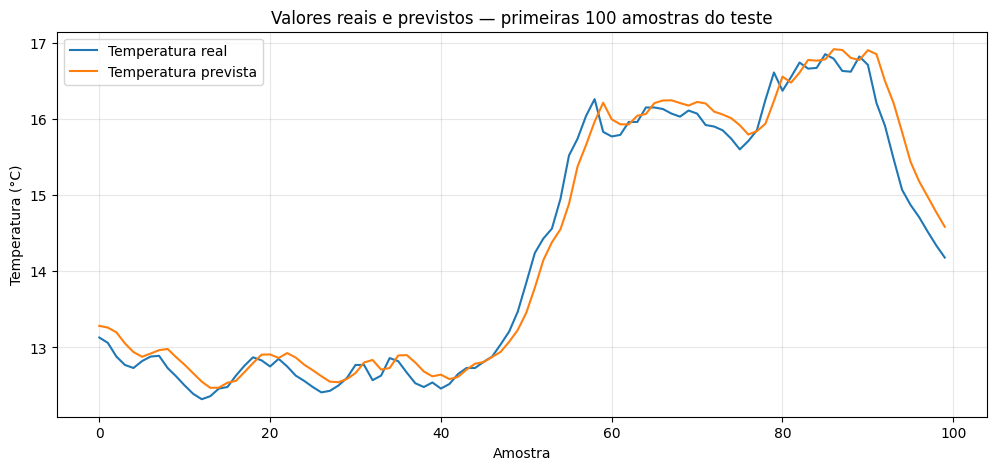

MAE no teste em °C — LSTM com 1 unidade: 0.2529


In [36]:
y_pred_1_scaled = model_1.predict(
    X_test,
    verbose=0,
)

y_test_celsius = scaler.inverse_transform(y_test)

y_pred_1_celsius = scaler.inverse_transform(
    y_pred_1_scaled
)

plt.figure(figsize=(12, 5))

plt.plot(
    y_test_celsius[:100, 0],
    label="Temperatura real",
)

plt.plot(
    y_pred_1_celsius[:100, 0],
    label="Temperatura prevista",
)

plt.title(
    "Valores reais e previstos — primeiras 100 amostras do teste"
)

plt.xlabel("Amostra")
plt.ylabel("Temperatura (°C)")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

mae_1_celsius = np.mean(
    np.abs(y_test_celsius - y_pred_1_celsius)
)

print(
    f"MAE no teste em °C — LSTM com 1 unidade: "
    f"{mae_1_celsius:.4f}"
)

O gráfico permite comparar diretamente as temperaturas medidas com as previsões do modelo. A LSTM com apenas uma unidade tende a acompanhar o comportamento geral da série, mas pode suavizar alterações rápidas e apresentar diferenças nos picos e vales. A qualidade da previsão deve ser avaliada observando a proximidade entre as curvas e o valor do erro absoluto médio, exibido pela célula anterior.

# <font color='green'><u><b>Parte 4 - Comparação de Arquiteturas</b></u></font>

### <font color='#2D9CDB'>Q11) Modifique a arquitetura da rede para utilizar 10 unidades na camada LSTM. Apresente o resumo da arquitetura gerado pelo método <code>summary()</code> e informe o número total de parâmetros treináveis do modelo. Em seguida, treine a rede por 10 épocas, avalie o modelo no conjunto de teste e reporte o valor de MSE obtido.</font>

In [37]:
model_10 = build_lstm_model(
    units=10,
    window_size=WINDOW_SIZE,
)

model_10.summary()

print("Parâmetros treináveis:", model_10.count_params())

history_10, time_epoch_10 = train_model(
    model=model_10,
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    epochs=10,
)

mse_10 = model_10.evaluate(
    X_test,
    y_test,
    verbose=0,
)

print(
    f"MSE no conjunto de teste — LSTM com 10 unidades: "
    f"{mse_10:.8f}"
)

print(
    f"Tempo médio por época — LSTM com 10 unidades: "
    f"{time_epoch_10:.3f} s"
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 10)             │           480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 491 (1.92 KB)

 Trainable params: 491 (1.92 KB)

 Non-trainable params: 0 (0.00 B)

Parâmetros treináveis: 491
Epoch 1/10
1972/1972 ━━━━━━━━━━━━━━━━━━━━ 29s 13ms/step - loss: 0.0021 - val_loss: 2.0982e-04
Epoch 2/10
1972/1972 ━━━━━━━━━━━━━━━━━━━━ 26s 13ms/step - loss: 1.2143e-04 - val_loss: 8.8270e-05
Epoch 3/10
1972/1972 ━━━━━━━━━━━━━━━━━━━━ 26s 13ms/step - loss: 7.6447e-05 - val_loss: 5.7923e-05
Epoch 4/10
1972/1972 ━━━━━━━━━━━━━━━━━━━━ 26s 13ms/step - loss: 5.7954e-05 - val_loss: 5.0116e-05
Epoch 5/10
1972/1972 ━━━━━━━━━━━━━━━━━━━━ 26s 13ms/step - loss: 4.1466e-05 - val_loss: 3.5475e-05
Epoch 6/10
1972/1972 ━━━━━━━━━━━━━━━━━━━━ 26s 13ms/step - loss: 3.1442e-05 - val_loss: 3.5008e-05
Epoch 7/10
1972/1972 ━━━━━━━━━━━━━━━━━━━━ 26s 13ms/step - loss: 2.5741e-05 - val_loss: 3.0778e-05
Epoch 8/10
1972/1972 ━━━━━━━━━━━━━━━━━━━━ 26s 13ms/step - loss: 2.2228e-05 - val_loss: 2.5710e-05
Epoch 9/10
1972/1972 ━━━━━━━━━━━━━━━━━━━━ 26s 13ms/step - loss: 1.9819e-05 - val_loss: 2.2468e-05
Epoch 10/10
1972/1972 ━━━━━━━━━━━━━━━━━━━━ 41s 13ms/step - loss: 1.8008e-05 - val_loss: 2.0167e

### <font color='#2D9CDB'>Q12) Repita o experimento utilizando 20 unidades na camada LSTM. Apresente o resumo da arquitetura gerado pelo método <code>summary()</code> e informe o número total de parâmetros treináveis do modelo. Em seguida, treine a rede por 10 épocas, avalie o modelo no conjunto de teste e reporte o valor de MSE obtido.</font>

In [38]:
model_20 = build_lstm_model(
    units=20,
    window_size=WINDOW_SIZE,
)

model_20.summary()

print("Parâmetros treináveis:", model_20.count_params())

history_20, time_epoch_20 = train_model(
    model=model_20,
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    epochs=10,
)

mse_20 = model_20.evaluate(
    X_test,
    y_test,
    verbose=0,
)

print(
    f"MSE no conjunto de teste — LSTM com 20 unidades: "
    f"{mse_20:.8f}"
)

print(
    f"Tempo médio por época — LSTM com 20 unidades: "
    f"{time_epoch_20:.3f} s"
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 20)             │         1,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,781 (6.96 KB)

 Trainable params: 1,781 (6.96 KB)

 Non-trainable params: 0 (0.00 B)

Parâmetros treináveis: 1781
Epoch 1/10
1972/1972 ━━━━━━━━━━━━━━━━━━━━ 33s 16ms/step - loss: 0.0012 - val_loss: 1.3426e-04
Epoch 2/10
1972/1972 ━━━━━━━━━━━━━━━━━━━━ 30s 15ms/step - loss: 1.0291e-04 - val_loss: 8.7328e-05
Epoch 3/10
1972/1972 ━━━━━━━━━━━━━━━━━━━━ 31s 16ms/step - loss: 6.2230e-05 - val_loss: 5.3165e-05
Epoch 4/10
1972/1972 ━━━━━━━━━━━━━━━━━━━━ 30s 15ms/step - loss: 4.7626e-05 - val_loss: 4.6456e-05
Epoch 5/10
1972/1972 ━━━━━━━━━━━━━━━━━━━━ 41s 15ms/step - loss: 3.6308e-05 - val_loss: 4.1189e-05
Epoch 6/10
1972/1972 ━━━━━━━━━━━━━━━━━━━━ 31s 16ms/step - loss: 2.7595e-05 - val_loss: 3.3599e-05
Epoch 7/10
1972/1972 ━━━━━━━━━━━━━━━━━━━━ 43s 17ms/step - loss: 2.1156e-05 - val_loss: 2.5447e-05
Epoch 8/10
1972/1972 ━━━━━━━━━━━━━━━━━━━━ 30s 15ms/step - loss: 1.7448e-05 - val_loss: 2.1716e-05
Epoch 9/10
1972/1972 ━━━━━━━━━━━━━━━━━━━━ 41s 16ms/step - loss: 1.5779e-05 - val_loss: 2.0690e-05
Epoch 10/10
1972/1972 ━━━━━━━━━━━━━━━━━━━━ 31s 16ms/step - loss: 1.5336e-05 - val_loss: 2.0160

### <font color='#2D9CDB'>Q13) Compare os modelos com 1, 10 e 20 unidades na camada LSTM em termos de número de parâmetros treináveis e desempenho no conjunto de teste. Organize os resultados em uma tabela contendo a quantidade de unidades LSTM, o número de parâmetros treináveis e o valor de MSE. Com base nos resultados obtidos, discuta brevemente a relação entre a complexidade do modelo e sua capacidade preditiva.</font>

In [39]:
results_units = pd.DataFrame({
    "Unidades LSTM": [
        1,
        10,
        20,
    ],
    "Parâmetros treináveis": [
        model_1.count_params(),
        model_10.count_params(),
        model_20.count_params(),
    ],
    "MSE no teste": [
        mse_1,
        mse_10,
        mse_20,
    ],
    "Tempo médio por época (s)": [
        time_epoch_1,
        time_epoch_10,
        time_epoch_20,
    ],
})

display(
    results_units.style.format({
        "MSE no teste": "{:.8f}",
        "Tempo médio por época (s)": "{:.3f}",
    })
)

best_units_row = results_units.loc[
    results_units["MSE no teste"].idxmin()
]

print(
    "Menor MSE entre as arquiteturas comparadas: "
    f"{int(best_units_row['Unidades LSTM'])} unidades "
    f"(MSE = {best_units_row['MSE no teste']:.8f})."
)

,Unidades LSTM,Parâmetros treináveis,MSE no teste,Tempo médio por época (s)
0,1,14,0.00003595,26.666
1,10,491,0.00002080,27.874
2,20,1781,0.00001984,34.254


Menor MSE entre as arquiteturas comparadas: 20 unidades (MSE = 0.00001984).


O aumento da quantidade de unidades amplia a capacidade da LSTM de representar padrões temporais, mas também aumenta o número de parâmetros e o custo computacional. A arquitetura com uma unidade é mais simples e pode apresentar subajuste. Os modelos com 10 e 20 unidades possuem maior capacidade preditiva. Entretanto, o ganho obtido pela rede com 20 unidades deve ser comparado com o aumento de complexidade e do tempo de treinamento. A tabela gerada permite verificar se a eventual redução do MSE compensa esse custo adicional.

# <font color='green'><u><b>Parte 5 - Influência da Janela Temporal</b></u></font>

### <font color='#2D9CDB'>Q14) Repita o experimento utilizando uma janela temporal de 15 amostras e uma camada LSTM com 10 unidades. Treine o modelo por 10 épocas, avalie o modelo no conjunto de teste e reporte o valor de MSE obtido.</font>

In [40]:
WINDOW_15 = 15

X_train_15, y_train_15 = create_sequences(
    train_scaled,
    WINDOW_15,
)

X_val_15, y_val_15 = create_sequences(
    val_scaled,
    WINDOW_15,
)

X_test_15, y_test_15 = create_sequences(
    test_scaled,
    WINDOW_15,
)

model_window_15 = build_lstm_model(
    units=10,
    window_size=WINDOW_15,
)

model_window_15.summary()

history_window_15, time_epoch_window_15 = train_model(
    model=model_window_15,
    X_train=X_train_15,
    y_train=y_train_15,
    X_val=X_val_15,
    y_val=y_val_15,
    epochs=10,
)

mse_window_15 = model_window_15.evaluate(
    X_test_15,
    y_test_15,
    verbose=0,
)

print(
    f"MSE no conjunto de teste — janela de 15 amostras: "
    f"{mse_window_15:.8f}"
)

print(
    f"Tempo médio por época — janela de 15 amostras: "
    f"{time_epoch_window_15:.3f} s"
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 10)             │           480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 491 (1.92 KB)

 Trainable params: 491 (1.92 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1972/1972 ━━━━━━━━━━━━━━━━━━━━ 18s 8ms/step - loss: 0.0022 - val_loss: 2.0153e-04
Epoch 2/10
1972/1972 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - loss: 1.8248e-04 - val_loss: 1.0463e-04
Epoch 3/10
1972/1972 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - loss: 7.5818e-05 - val_loss: 5.5863e-05
Epoch 4/10
1972/1972 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - loss: 4.9923e-05 - val_loss: 4.5264e-05
Epoch 5/10
1972/1972 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - loss: 4.0844e-05 - val_loss: 4.2652e-05
Epoch 6/10
1972/1972 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - loss: 3.4289e-05 - val_loss: 3.8416e-05
Epoch 7/10
1972/1972 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - loss: 2.9471e-05 - val_loss: 3.1867e-05
Epoch 8/10
1972/1972 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - loss: 2.5366e-05 - val_loss: 2.7237e-05
Epoch 9/10
1972/1972 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 2.2205e-05 - val_loss: 2.4419e-05
Epoch 10/10
1972/1972 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - loss: 1.9554e-05 - val_loss: 2.0777e-05
MSE no conjunto de teste — janela

### <font color='#2D9CDB'>Q15) Repita o experimento utilizando uma janela temporal de 60 amostras e uma camada LSTM com 10 unidades. Treine o modelo por 10 épocas, avalie o modelo no conjunto de teste e reporte o valor de MSE obtido.</font>

In [41]:
WINDOW_60 = 60

X_train_60, y_train_60 = create_sequences(
    train_scaled,
    WINDOW_60,
)

X_val_60, y_val_60 = create_sequences(
    val_scaled,
    WINDOW_60,
)

X_test_60, y_test_60 = create_sequences(
    test_scaled,
    WINDOW_60,
)

model_window_60 = build_lstm_model(
    units=10,
    window_size=WINDOW_60,
)

model_window_60.summary()

history_window_60, time_epoch_window_60 = train_model(
    model=model_window_60,
    X_train=X_train_60,
    y_train=y_train_60,
    X_val=X_val_60,
    y_val=y_val_60,
    epochs=10,
)

mse_window_60 = model_window_60.evaluate(
    X_test_60,
    y_test_60,
    verbose=0,
)

print(
    f"MSE no conjunto de teste — janela de 60 amostras: "
    f"{mse_window_60:.8f}"
)

print(
    f"Tempo médio por época — janela de 60 amostras: "
    f"{time_epoch_window_60:.3f} s"
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 10)             │           480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 491 (1.92 KB)

 Trainable params: 491 (1.92 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1971/1971 ━━━━━━━━━━━━━━━━━━━━ 48s 23ms/step - loss: 0.0021 - val_loss: 2.4657e-04
Epoch 2/10
1971/1971 ━━━━━━━━━━━━━━━━━━━━ 82s 23ms/step - loss: 1.2104e-04 - val_loss: 1.0140e-04
Epoch 3/10
1971/1971 ━━━━━━━━━━━━━━━━━━━━ 81s 23ms/step - loss: 8.0218e-05 - val_loss: 6.0538e-05
Epoch 4/10
1971/1971 ━━━━━━━━━━━━━━━━━━━━ 50s 26ms/step - loss: 5.6640e-05 - val_loss: 4.9286e-05
Epoch 5/10
1971/1971 ━━━━━━━━━━━━━━━━━━━━ 50s 25ms/step - loss: 3.9408e-05 - val_loss: 3.8988e-05
Epoch 6/10
1971/1971 ━━━━━━━━━━━━━━━━━━━━ 77s 23ms/step - loss: 3.0568e-05 - val_loss: 4.3623e-05
Epoch 7/10
1971/1971 ━━━━━━━━━━━━━━━━━━━━ 82s 23ms/step - loss: 2.5429e-05 - val_loss: 3.8240e-05
Epoch 8/10
1971/1971 ━━━━━━━━━━━━━━━━━━━━ 45s 23ms/step - loss: 2.1982e-05 - val_loss: 3.1658e-05
Epoch 9/10
1971/1971 ━━━━━━━━━━━━━━━━━━━━ 45s 23ms/step - loss: 1.9585e-05 - val_loss: 2.7093e-05
Epoch 10/10
1971/1971 ━━━━━━━━━━━━━━━━━━━━ 45s 23ms/step - loss: 1.7878e-05 - val_loss: 2.4483e-05
MSE no conjunto de test

### <font color='#2D9CDB'>Q16) Compare os resultados obtidos para janelas temporais de 15, 30 e 60 amostras utilizando uma camada LSTM com 10 unidades. Organize os resultados em uma tabela contendo o tamanho da janela temporal, o valor de MSE e uma estimativa do tempo médio de treinamento por época (dica: utilize os valores exibidos nos logs de treinamento). Com base nos resultados, discuta brevemente o impacto do tamanho da janela temporal no desempenho e no custo computacional do modelo.</font>

In [42]:
results_windows = pd.DataFrame({
    "Janela temporal": [
        15,
        30,
        60,
    ],
    "Unidades LSTM": [
        10,
        10,
        10,
    ],
    "MSE no teste": [
        mse_window_15,
        mse_10,
        mse_window_60,
    ],
    "Tempo médio por época (s)": [
        time_epoch_window_15,
        time_epoch_10,
        time_epoch_window_60,
    ],
})

display(
    results_windows.style.format({
        "MSE no teste": "{:.8f}",
        "Tempo médio por época (s)": "{:.3f}",
    })
)

best_window_row = results_windows.loc[
    results_windows["MSE no teste"].idxmin()
]

print(
    "Menor MSE entre as janelas comparadas: "
    f"janela de {int(best_window_row['Janela temporal'])} amostras "
    f"(MSE = {best_window_row['MSE no teste']:.8f})."
)

,Janela temporal,Unidades LSTM,MSE no teste,Tempo médio por época (s)
0,15,10,0.00002070,17.006
1,30,10,0.00002080,27.874
2,60,10,0.00002366,60.500


Menor MSE entre as janelas comparadas: janela de 15 amostras (MSE = 0.00002070).


Uma janela temporal maior fornece mais informações históricas para a LSTM, mas também aumenta a quantidade de operações necessárias para processar cada sequência. Consequentemente, o custo computacional tende a crescer. Uma janela muito curta pode não fornecer contexto suficiente para a previsão. Por outro lado, uma janela muito longa nem sempre melhora o resultado e pode elevar o tempo de treinamento sem oferecer uma redução significativa do erro. A tabela permite comparar diretamente o desempenho e o custo computacional das janelas de 15, 30 e 60 amostras.

# <font color='green'><u><b>Parte 6 - Análise Final</b></u></font>

### <font color='#2D9CDB'>Q17) Com base em todos os experimentos realizados nesta atividade, discuta os fatores que mais influenciaram o desempenho do modelo. Considere o impacto da quantidade de unidades LSTM, do tamanho da janela temporal e do custo computacional. Em sua opinião, qual configuração apresentou o melhor equilíbrio entre precisão e eficiência? Justifique sua resposta.</font>

Os experimentos mostram que o desempenho da LSTM depende principalmente da quantidade de unidades de memória e do tamanho da janela temporal. O modelo com apenas **1 unidade LSTM** apresenta menor custo computacional, mas possui capacidade limitada para representar padrões mais complexos da série. Ao aumentar para **10 unidades**, o modelo passa a capturar melhor as variações temporais, mantendo um tempo de treinamento aceitável. Já a configuração com **20 unidades** possui mais parâmetros treináveis e exige maior processamento, mas o ganho de precisão não necessariamente compensa o aumento da complexidade. Em relação à janela temporal, a janela de **15 amostras** utiliza menos informações anteriores e reduz o custo computacional, porém pode não fornecer contexto suficiente para a previsão. A janela de **60 amostras** oferece um histórico maior, mas aumenta o tempo de processamento sem garantir uma redução proporcional do erro. A janela de **30 amostras** representa um ponto intermediário adequado, pois fornece contexto temporal suficiente sem elevar excessivamente o custo computacional. Portanto, considerando o equilíbrio entre precisão, quantidade de parâmetros e tempo de treinamento, a configuração com **10 unidades LSTM e janela temporal de 30 amostras** apresentou a melhor relação entre desempenho e eficiência entre os modelos analisados.